In [2]:
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv("../data/cleaned_superstore_data.csv",parse_dates=['order_date', 'ship_date'])

# Sales by Category

In [4]:
category_sales = df.groupby('category')['sales'].sum()

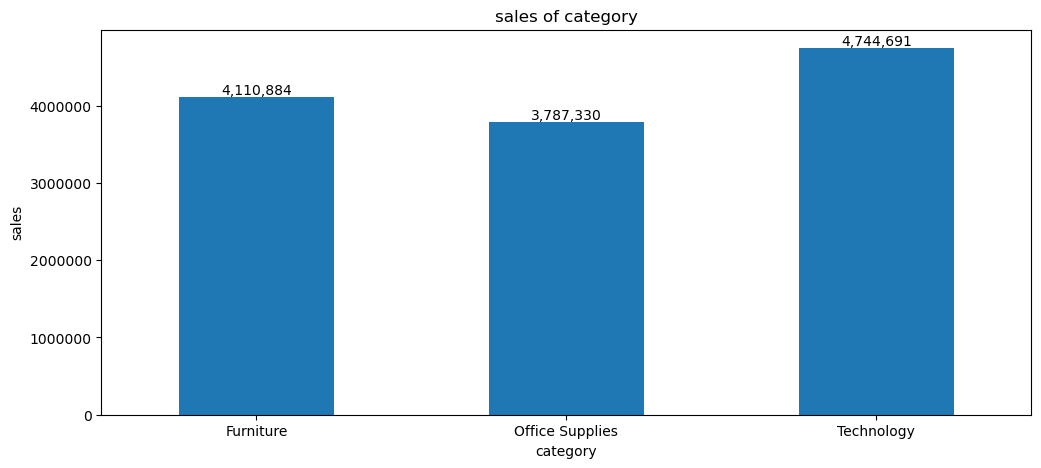

In [26]:
bars = category_sales.plot(kind ='bar' ,figsize =(12,5))
bars.bar_label(bars.containers[0] ,fmt='{:,.0f}')
plt.title('sales of category')
plt.ylabel('sales')
plt.xlabel('category')
plt.xticks(rotation = 0)
plt.ticklabel_format(style='plain', axis='y')
plt.show()

# Profit by Region

In [6]:
region_profit = df.groupby('region')['profit'].sum()

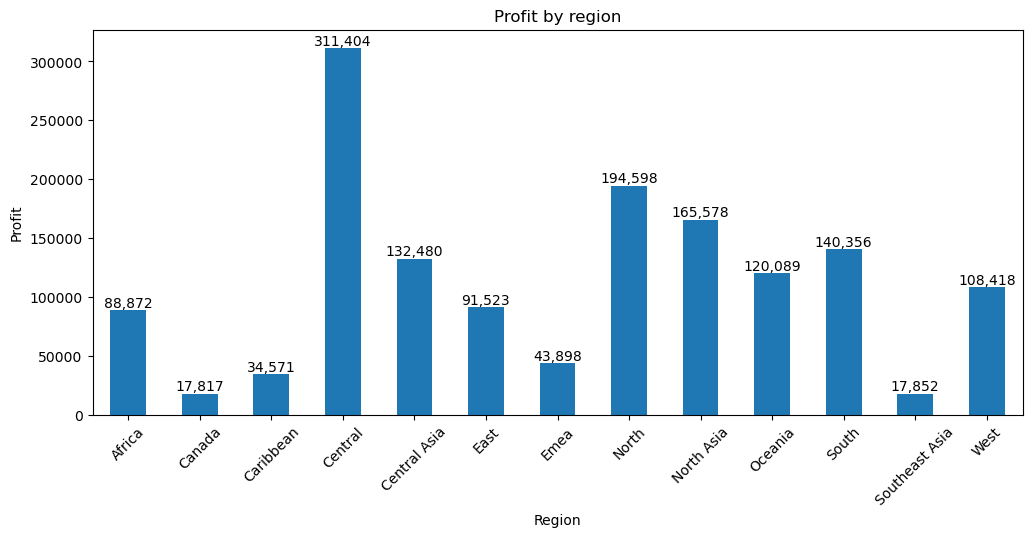

In [7]:
bars = region_profit.plot(kind ='bar' ,figsize =(12,5))
bars.bar_label(bars.containers[0] , fmt = '{:,.0f}')
plt.title('Profit by region')
plt.ylabel('Profit')
plt.xlabel('Region')
plt.xticks(rotation = 45)
plt.show()

# Monthly Sales Trend

In [8]:
monthly_sales = df.groupby(df['order_date'].dt.to_period('M'))['sales'].sum()

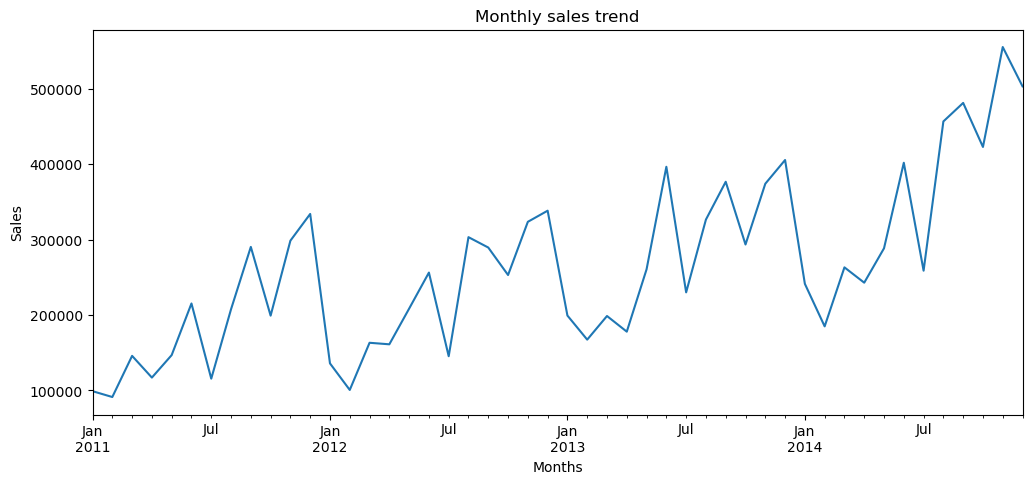

In [9]:
bars = monthly_sales.plot(figsize= (12,5))
plt.title('Monthly sales trend')
plt.ylabel('Sales')
plt.xlabel('Months')

plt.show()

# Profit by Sub-Category

In [10]:
subcategory_profit = df.groupby('sub_category')['profit'].sum()

(array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16]),
 [Text(0, 0, 'Accessories'),
  Text(1, 0, 'Appliances'),
  Text(2, 0, 'Art'),
  Text(3, 0, 'Binders'),
  Text(4, 0, 'Bookcases'),
  Text(5, 0, 'Chairs'),
  Text(6, 0, 'Copiers'),
  Text(7, 0, 'Envelopes'),
  Text(8, 0, 'Fasteners'),
  Text(9, 0, 'Furnishings'),
  Text(10, 0, 'Labels'),
  Text(11, 0, 'Machines'),
  Text(12, 0, 'Paper'),
  Text(13, 0, 'Phones'),
  Text(14, 0, 'Storage'),
  Text(15, 0, 'Supplies'),
  Text(16, 0, 'Tables')])

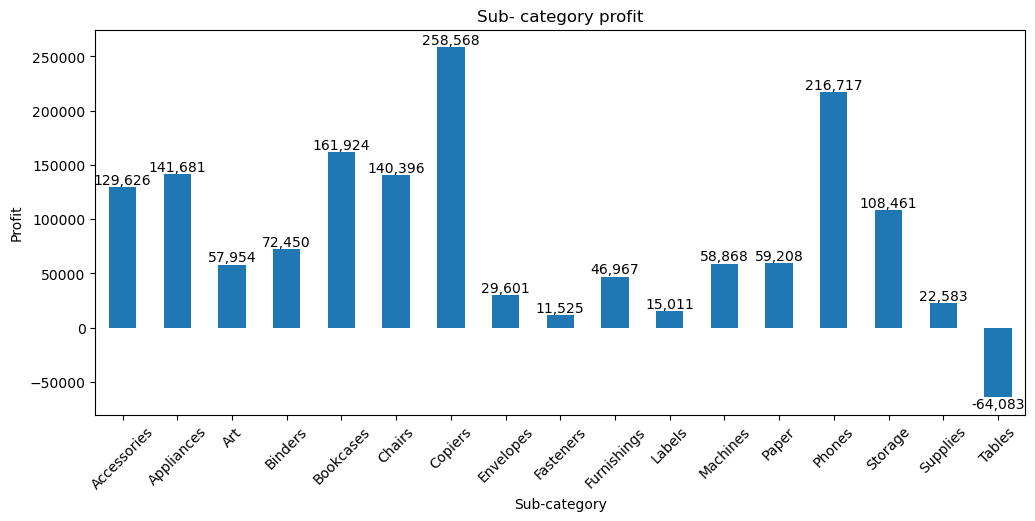

In [13]:
bars = subcategory_profit.plot(kind ='bar' , figsize=(12,5))
bars.bar_label(bars.containers[0], fmt ='{:,.0f}')
plt.title('Sub- category profit')
plt.xlabel('Sub-category')
plt.ylabel('Profit')
plt.xticks(rotation =45)

# Discount vs Profit
# Observation:- Higher discount levels are associated with lower profits.
- Many high-discount orders resulted in negative profit, indicating that aggressive discount strategies may reduce overall profitability.y.

In [28]:
df[['profit','discount']].corr()

,profit,discount
profit,1.00000,-0.31649
discount,-0.31649,1.00000


Text(0, 0.5, 'Profit')

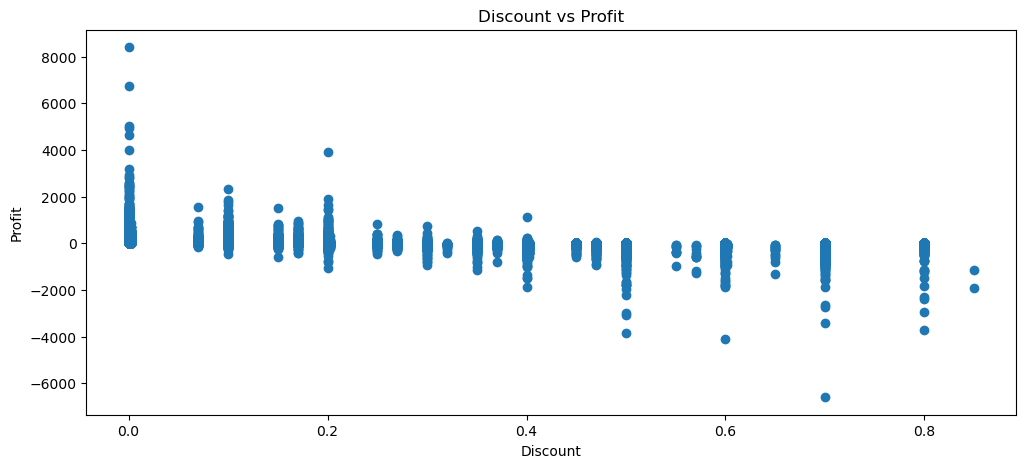

In [30]:
plt.figure(figsize = (12,5))
plt.scatter(df['discount'] , df['profit'])
plt.title('Discount vs Profit')
plt.xlabel('Discount')
plt.ylabel('Profit')

# Sales by Segment

In [31]:
segment_sales = df.groupby('segment')['sales'].sum()

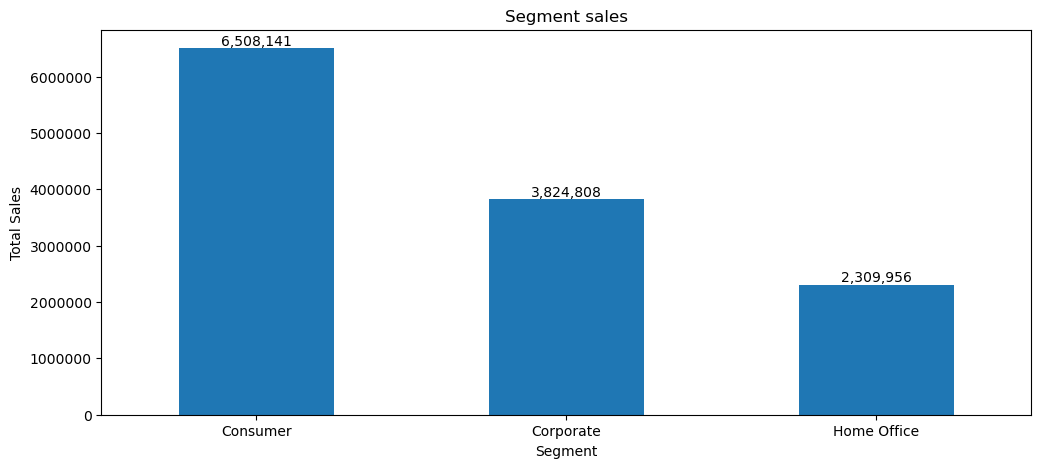

In [35]:
bars = segment_sales.plot(kind = 'bar' ,figsize = (12,5))
bars.bar_label(bars.containers[0] , fmt ='{:,.0f}')
plt.ticklabel_format(style = 'plain' ,axis ='y')
plt.xticks(rotation =0)
plt.title('Segment sales')
plt.xlabel('Segment')
plt.ylabel('Total Sales')
plt.show()

# Delivery Time by Ship Mode

In [15]:
df['delivery_days'] = (df['ship_date'] - df['order_date']).dt.days 

In [16]:
efficient_ship_mode = df.groupby('ship_mode')['delivery_days'].mean()

(array([0, 1, 2, 3]),
 [Text(0, 0, 'First Class'),
  Text(1, 0, 'Same Day'),
  Text(2, 0, 'Second Class'),
  Text(3, 0, 'Standard Class')])

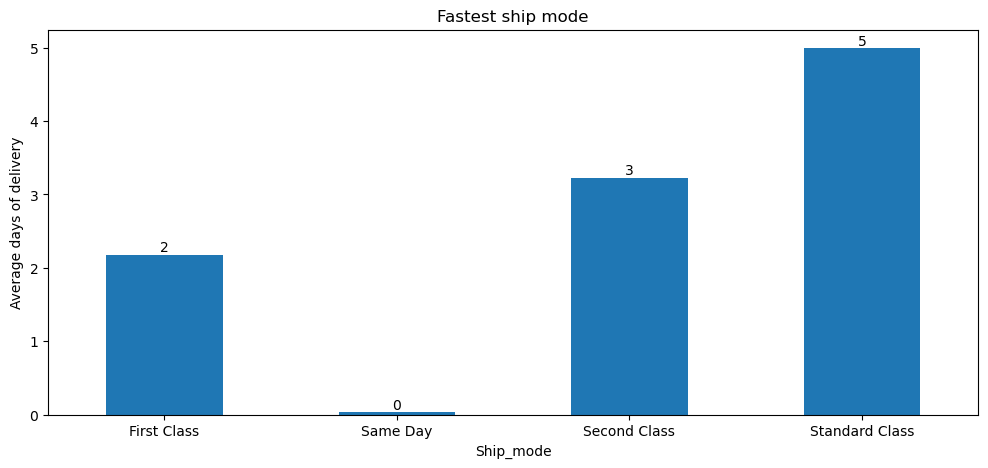

In [25]:
bars = efficient_ship_mode.plot(kind ='bar' , figsize=(12,5))
bars.bar_label(bars.containers[0] , fmt = '{:,.0f}')
plt.title('Fastest ship mode')
plt.xlabel('Ship_mode')
plt.ylabel('Average days of delivery')
plt.xticks(rotation = 0)